<a href="https://colab.research.google.com/github/jashwanth-cse/Jashwanth-Codeboosters-Internship-2026/blob/main/Phase_01_Data_Engineering/Phase1_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.filterwarnings('ignore')
print("pandas version:",pd.__version__)
print("sqlite3 version:",sqlite3.version)

pandas version: 2.2.2
sqlite3 version: 2.6.0


In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Data ingestion
df=pd.read_csv('/content/drive/MyDrive/spotify_tracks.csv')
print(f"Dataset loaded:{df.shape[0]} tracks,{df.shape[1]} columns")


Dataset loaded:62317 tracks,22 columns


In [4]:
print("--------Data understanding---------------")
print(df.columns.tolist())
#No.of rows & columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

#Displays 5 random rows from your dataset.
print(df.sample(5))

print("Column names:",df.columns.tolist())

--------Data understanding---------------
['track_id', 'track_name', 'artist_name', 'year', 'popularity', 'artwork_url', 'album_name', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'track_url', 'language']
Rows: 62317
Columns: 22
                     track_id                     track_name  \
39955  3KBK1OAkwROhgq0Y0nTCDA        Maalai Suda Kanne Radha   
57896  64enq1PbOvk8oYNFYeRKXW                 The Cool Crowd   
24582  7AaLAJuJyA5E9K9jkTIeUz  Airplane pt.2 - Japanese ver.   
1857   31h9GrVUuopQoEPYTTYgTX                     Melam Moge   
35531  2zksab3j48da3ZlSvT6m0i                    World war 8   

                                             artist_name  year  popularity  \
39955  Ilaiyaraaja, S. P. Balasubrahmanyam, S. P. Sai...  1982           4   
57896                            Daniel Alexis Pemberton  2010           0   
24582                       

Dataset Summary

Total Records : 62317
Total Features : 22
Missing Values : 0
Duplicate Records : 78

The dataset contains Spotify songs along with audio features such as energy, danceability, acousticness, tempo, and popularity.

In [5]:
print("--------Data Cleaning & Preprocessing---------------")

# Missing Values Check
print("\nChecking Missing Values...")
print(df.isnull().sum())

total_missing = df.isnull().sum().sum()
print("\nTotal Missing Values:", total_missing)

if total_missing == 0:
    print("No missing values found.")
else:
    print("Missing values detected.")

# Duplicate Records Check
print("\nChecking Duplicate Records...")
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

# Remove Duplicates
print("\nRemoving Duplicate Records...")
df = df.drop_duplicates()

print("Duplicate Records After Removal:", df.duplicated().sum())

# Data Types Check
print("\nChecking Data Types...")
print(df.dtypes)

# Rename Columns for Better Readability
print("\nRenaming Columns...")

df.rename(columns={
    'track_id':'song_id',
    'track_name':'song_name',
    'artist_name':'artist',
    'duration_ms':'duration_milliseconds'
}, inplace=True)

print("Updated Column Names:")
print(df.columns.tolist())

# Create New Derived Column
print("\nCreating Duration in Minutes Column...")

df['duration_minutes'] = round(
    df['duration_milliseconds'] / 60000, 2
)

print(df[['duration_milliseconds','duration_minutes']].head())

# Final Validation
print("\nFinal Validation")
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Records:", df.duplicated().sum())

# Save Cleaned Dataset
df.to_csv(
    '/content/drive/MyDrive/spotify_tracks_cleaned.csv',
    index=False
)

print("\nCleaned dataset saved successfully!")
print("File: spotify_tracks_cleaned.csv")

--------Data Cleaning & Preprocessing---------------

Checking Missing Values...
track_id            0
track_name          0
artist_name         0
year                0
popularity          0
artwork_url         0
album_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
track_url           0
language            0
dtype: int64

Total Missing Values: 0
No missing values found.

Checking Duplicate Records...
Duplicate Records: 78

Removing Duplicate Records...
Duplicate Records After Removal: 0

Checking Data Types...
track_id             object
track_name           object
artist_name          object
year                  int64
popularity            int64
artwork_url          object
album_name           object
acousticness        float64
dance

Data Cleaning and Preprocessing
* Checked the dataset for missing values.
* No missing values were found.
* Identified 78 duplicate records.
* Removed duplicate records.
* Reviewed data types and confirmed correctness.
* Renamed selected columns for better         readability.
* Created a new column named duration_minutes.
* Saved the cleaned dataset as spotify_tracks_cleaned.csv.

In [6]:
print("--------SQLite Database Integration---------------")

# Create SQLite Connection
conn = sqlite3.connect('spotify_analysis.db')

print("Database created successfully!")

# Load DataFrame into SQLite Table
df.to_sql(
    'spotify_tracks',
    conn,
    if_exists='replace',
    index=False
)

print("Dataset loaded into SQLite table successfully!")

# Verify Record Count
query = """
SELECT COUNT(*) AS total_records
FROM spotify_tracks
"""

record_count = pd.read_sql(query, conn)

print("\nVerifying Data Insertion...")
print(record_count)

# Display First 5 Records
query = """
SELECT *
FROM spotify_tracks
LIMIT 5
"""

sample_data = pd.read_sql(query, conn)

print("\nFirst 5 Records from Database:")
print(sample_data)

print("\nDatabase Integration Completed Successfully!")

--------SQLite Database Integration---------------
Database created successfully!
Dataset loaded into SQLite table successfully!

Verifying Data Insertion...
   total_records
0          62239

First 5 Records from Database:
                  song_id                                   song_name  \
0  2r0ROhr7pRN4MXDMT1fEmd                  Leo Das Entry (From "Leo")   
1  4I38e6Dg52a2o2a8i5Q5PW                                AAO KILLELLE   
2  59NoiRhnom3lTeRFaBzOev      Mayakiriye Sirikiriye - Orchestral EDM   
3  5uUqRQd385pvLxC8JX3tXn    Scene Ah Scene Ah - Experimental EDM Mix   
4  1KaBRg2xgNeCljmyxBH1mo  Gundellonaa X I Am A Disco Dancer - Mashup   

                                              artist  year  popularity  \
0                                Anirudh Ravichander  2024          59   
1  Anirudh Ravichander, Pravin Mani, Vaishali Sri...  2024          47   
2           Anirudh Ravichander, Anivee, Alvin Bruno  2024          35   
3  Anirudh Ravichander, Bharath Sankar, K

SQLite Database Integration

*  Created a SQLite database named spotify_analysis.db.
*  Loaded the cleaned Spotify dataset into a table named spotify_tracks.
*  Verified successful insertion by counting records.
*  Retrieved sample records from the database for validation.

In [7]:
print("--------SQL Query 1 : Filtering---------------")
#Songs with popularity>90
query = """
SELECT song_name, artist, language, popularity
FROM spotify_tracks
WHERE popularity > 90
ORDER BY popularity DESC
LIMIT 20;
"""

result = pd.read_sql(query, conn)

print(result)

--------SQL Query 1 : Filtering---------------
         song_name                 artist language  popularity
0        Big Dawgs     Hanumankind, Kalmi  English          93
1  Blinding Lights             The Weeknd  English          91
2          Starboy  The Weeknd, Daft Punk  English          91


In [8]:
print("--------SQL Query 2 : Sorting---------------")
#Top 10 Most Popular Songs
query = """
SELECT song_name, artist, popularity
FROM spotify_tracks
ORDER BY popularity DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

print(result)

--------SQL Query 2 : Sorting---------------
                                           song_name  \
0                                          Big Dawgs   
1                                    Blinding Lights   
2                                            Starboy   
3  Bye Bye Bye - From Deadpool and Wolverine Soun...   
4                                          Anti-Hero   
5                                           cardigan   
6                           Something Just Like This   
7                                     Counting Stars   
8  Is It Over Now? (Taylor's Version) (From The V...   
9                                             august   

                       artist  popularity  
0          Hanumankind, Kalmi          93  
1                  The Weeknd          91  
2       The Weeknd, Daft Punk          91  
3                      *NSYNC          90  
4                Taylor Swift          89  
5                Taylor Swift          89  
6  The Chainsmokers, Coldplay 

In [9]:
print("--------SQL Query 3 : Aggregation---------------")
#average popularity of all songs?
query = """
SELECT
AVG(popularity) AS average_popularity,
MAX(popularity) AS highest_popularity,
MIN(popularity) AS lowest_popularity
FROM spotify_tracks;
"""

result = pd.read_sql(query, conn)

print(result)

--------SQL Query 3 : Aggregation---------------
   average_popularity  highest_popularity  lowest_popularity
0           15.357589                  93                  0


In [10]:
print("--------SQL Query 4 : Group By---------------")
#Top music language
query = """
SELECT
language,
COUNT(*) AS total_songs,
ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY language
ORDER BY avg_popularity DESC;
"""

result = pd.read_sql(query, conn)

print(result)

--------SQL Query 4 : Group By---------------
    language  total_songs  avg_popularity
0     Korean         6893           27.55
1      Hindi         5740           18.20
2    English        23389           14.76
3     Telugu          321           14.32
4    Unknown        13005           12.26
5      Tamil        12609           11.91
6  Malayalam          282            7.32


In [11]:
print("--------SQL Query 5 : Conditional Query---------------")
#songs based on popularity
query = """
SELECT
song_name,
artist,
popularity,

CASE
    WHEN popularity >= 80 THEN 'Hit Song'
    WHEN popularity >= 50 THEN 'Average Song'
    ELSE 'Low Popularity'
END AS popularity_category

FROM spotify_tracks
LIMIT 20;
"""

result = pd.read_sql(query, conn)

print(result)

--------SQL Query 5 : Conditional Query---------------
                                     song_name  \
0                   Leo Das Entry (From "Leo")   
1                                 AAO KILLELLE   
2       Mayakiriye Sirikiriye - Orchestral EDM   
3     Scene Ah Scene Ah - Experimental EDM Mix   
4   Gundellonaa X I Am A Disco Dancer - Mashup   
5      Villain Yevadu Ra (From "Leo (Telugu)")   
6                      Gundellonaa - Pop Kuthu   
7                     Knockout Song - Funk Mix   
8                   Rathamaarey (LoFi Version)   
9                     Theeraamal - Ambient Mix   
10                      Nagarathey - Dance Mix   
11       Villain Kaun Hai (From "Leo (Hindi)")   
12      Villain Yaarava (From "Leo (Kannada)")   
13     Villain Aarada (From "Leo (Malayalam)")   
14                  Nagarathey - Synthwave Mix   
15                Knockout Song - Ambient Lofi   
16                   Theeraamal - Ambient Lofi   
17          Ezhundhu Vaa (From "Singappenney"

In [12]:
print("--------SQL Based Data Transformation---------------")

query = """
SELECT *,

CASE
    WHEN popularity >= 80 THEN 'Hit Song'
    WHEN popularity >= 50 THEN 'Average Song'
    ELSE 'Low Popularity'
END AS popularity_category,

CASE
    WHEN energy >= 0.7 THEN 'High Energy'
    WHEN energy >= 0.4 THEN 'Medium Energy'
    ELSE 'Low Energy'
END AS energy_category

FROM spotify_tracks;
"""

transformed_df = pd.read_sql(query, conn)

print("Transformation completed successfully!")
print()

print("New Dataset Shape:", transformed_df.shape)
print()

print(transformed_df[['song_name',
                      'popularity',
                      'popularity_category',
                      'energy',
                      'energy_category']].head())

--------SQL Based Data Transformation---------------
Transformation completed successfully!

New Dataset Shape: (62239, 25)

                                    song_name  popularity popularity_category  \
0                  Leo Das Entry (From "Leo")          59        Average Song   
1                                AAO KILLELLE          47      Low Popularity   
2      Mayakiriye Sirikiriye - Orchestral EDM          35      Low Popularity   
3    Scene Ah Scene Ah - Experimental EDM Mix          24      Low Popularity   
4  Gundellonaa X I Am A Disco Dancer - Mashup          22      Low Popularity   

   energy energy_category  
0   0.970     High Energy  
1   0.793     High Energy  
2   0.491   Medium Energy  
3   0.630   Medium Energy  
4   0.748     High Energy  


In [13]:
transformed_df.to_csv(
    '/content/drive/MyDrive/spotify_tracks_transformed.csv',
    index=False
)

print("Transformed dataset exported successfully!")

Transformed dataset exported successfully!


SQL-Based Data Transformation

• Created a new column called popularity_category using CASE statements.

• Songs were classified as Hit Song, Average Song, or Low Popularity based on popularity scores.

• Created a second column called energy_category using CASE statements.

• Songs were classified as High Energy, Medium Energy, or Low Energy based on energy values.

• Exported the transformed dataset as spotify_tracks_transformed.csv.

In [14]:
print("--------ETL Pipeline---------------")

# EXTRACT
print("\nEXTRACT STAGE")
data = pd.read_csv('/content/drive/MyDrive/spotify_tracks.csv')
print("Dataset extracted successfully!")
print("Shape:", data.shape)

# TRANSFORM
print("\nTRANSFORM STAGE")

# Remove duplicates
data = data.drop_duplicates()

# Rename columns
data.rename(columns={
    'track_id':'song_id',
    'track_name':'song_name',
    'artist_name':'artist'
}, inplace=True)

# Create duration in minutes
data['duration_minutes'] = round(data['duration_ms'] / 60000, 2)

print("Data transformed successfully!")
print("New Shape:", data.shape)

# LOAD
print("\nLOAD STAGE")

data.to_csv(
    '/content/drive/MyDrive/spotify_etl_output.csv',
    index=False
)

print("Processed dataset loaded successfully!")
print("File saved as spotify_etl_output.csv")

--------ETL Pipeline---------------

EXTRACT STAGE
Dataset extracted successfully!
Shape: (62317, 22)

TRANSFORM STAGE
Data transformed successfully!
New Shape: (62239, 23)

LOAD STAGE
Processed dataset loaded successfully!
File saved as spotify_etl_output.csv


ETL Pipeline

Extract:
- Read the Spotify dataset from CSV file.

Transform:
- Removed duplicate records.
- Renamed columns for better readability.
- Created duration_minutes column.

Load:
- Saved the processed dataset into a new CSV file.

In [15]:
!pip install pyspark

In [16]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Spotify Medallion Architecture") \
    .getOrCreate()

print("Spark Session Created Successfully!")


Spark Session Created Successfully!


In [17]:
print("--------BRONZE LAYER--------")

bronze_df = spark.read.csv(
    "/content/drive/MyDrive/spotify_tracks.csv",
    header=True,
    inferSchema=True
)

bronze_df.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/bronze_spotify"
)

print("Bronze Layer Created!")
bronze_df.show(5)

--------BRONZE LAYER--------
Bronze Layer Created!
+--------------------+--------------------+--------------------+----+----------+--------------------+--------------------+------------+------------+-----------+------+----------------+----+--------+--------+----+-----------+-------+--------------+-------+--------------------+--------+
|            track_id|          track_name|         artist_name|year|popularity|         artwork_url|          album_name|acousticness|danceability|duration_ms|energy|instrumentalness| key|liveness|loudness|mode|speechiness|  tempo|time_signature|valence|           track_url|language|
+--------------------+--------------------+--------------------+----+----------+--------------------+--------------------+------------+------------+-----------+------+----------------+----+--------+--------+----+-----------+-------+--------------+-------+--------------------+--------+
|2r0ROhr7pRN4MXDMT...|"Leo Das Entry (F...| Anirudh Ravichander|2024|        59|https://i.s

In [35]:
print("--------SILVER LAYER--------")

silver_df = bronze_df.dropDuplicates()

silver_df = silver_df.na.drop()

silver_df.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/silver_spotify"
)

print("Silver Layer Created!")
silver_df.show(5)

--------SILVER LAYER--------
Silver Layer Created!
+--------------------+--------------------+--------------------+----+----------+--------------------+--------------------+------------+------------+-----------+------+----------------+---+--------+--------+----+-----------+-------+--------------+-------+--------------------+--------+
|            track_id|          track_name|         artist_name|year|popularity|         artwork_url|          album_name|acousticness|danceability|duration_ms|energy|instrumentalness|key|liveness|loudness|mode|speechiness|  tempo|time_signature|valence|           track_url|language|
+--------------------+--------------------+--------------------+----+----------+--------------------+--------------------+------------+------------+-----------+------+----------------+---+--------+--------+----+-----------+-------+--------------+-------+--------------------+--------+
|6Zug99zBSV4A94tLh...|Muthuvel Pandian ...| Anirudh Ravichander|2023|        20|https://i.scdn

In [36]:
from pyspark.sql.functions import avg, count
from pyspark.sql.functions import col

print("--------GOLD LAYER--------")

# Keep only rows where popularity looks numeric
gold_source = silver_df.filter(
    col("popularity").rlike("^[0-9]+$")
)

# Convert popularity to double
gold_source = gold_source.withColumn(
    "popularity_num",
    col("popularity").cast("double")
)

# Create KPI dataset
gold_df = gold_source.groupBy("language").agg(
    count("*").alias("total_songs"),
    avg("popularity_num").alias("avg_popularity")
)

gold_df.show()

# Save Gold Layer
gold_df.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/gold_spotify"
)

print("Gold Layer Saved Successfully!")

--------GOLD LAYER--------
+--------------------+-----------+------------------+
|            language|total_songs|    avg_popularity|
+--------------------+-----------+------------------+
|https://open.spot...|          1|            1999.0|
|https://open.spot...|          1|            2024.0|
|https://open.spot...|          1|            2003.0|
|https://open.spot...|          1|            2018.0|
|https://open.spot...|          1|            2005.0|
|https://open.spot...|          1|            1999.0|
|https://open.spot...|          1|            1999.0|
|              Telugu|        321|14.320872274143301|
|https://open.spot...|          1|            1999.0|
|             English|      23370|14.762045357295678|
|             Unknown|      12995|12.261254328587919|
|               Tamil|      12607|11.912112318553184|
|https://open.spot...|          1|            2003.0|
|              Korean|       6893| 27.54809226751777|
|               Hindi|       5738|18.182293482049495|
|

In [37]:
print("Bronze Records:", bronze_df.count())
print("Silver Records:", silver_df.count())
print("Gold Records:", gold_df.count())

Bronze Records: 62317
Silver Records: 62239
Gold Records: 36


In [38]:
print("--------Parquet to Pandas Conversion--------")

gold_parquet = spark.read.parquet(
    "/content/drive/MyDrive/gold_spotify"
)

print("Parquet File Loaded Successfully!")

gold_parquet.show()

--------Parquet to Pandas Conversion--------
Parquet File Loaded Successfully!
+--------------------+-----------+------------------+
|            language|total_songs|    avg_popularity|
+--------------------+-----------+------------------+
|https://open.spot...|          1|            1999.0|
|https://open.spot...|          1|            2024.0|
|https://open.spot...|          1|            2003.0|
|https://open.spot...|          1|            2018.0|
|https://open.spot...|          1|            2005.0|
|https://open.spot...|          1|            1999.0|
|https://open.spot...|          1|            1999.0|
|              Telugu|        321|14.320872274143301|
|https://open.spot...|          1|            1999.0|
|             English|      23370|14.762045357295678|
|             Unknown|      12995|12.261254328587919|
|               Tamil|      12607|11.912112318553184|
|https://open.spot...|          1|            2003.0|
|              Korean|       6893| 27.54809226751777|
|  

In [ ]:
gold_pandas = gold_parquet.toPandas()

print("Converted to Pandas DataFrame!")
print()

print(gold_pandas.head())

print("Shape:", gold_pandas.shape)
print("Columns:", gold_pandas.columns.tolist())

PySpark Medallion Architecture

Bronze Layer
- Raw Spotify dataset ingested and stored as Parquet.

Silver Layer
- Removed duplicate and null records.
- Stored cleaned data as Parquet.

Gold Layer
- Generated business-ready KPI dataset.
- Calculated total songs and average popularity by language.
- Stored aggregated data as Parquet.

---------Data Visualization--------------




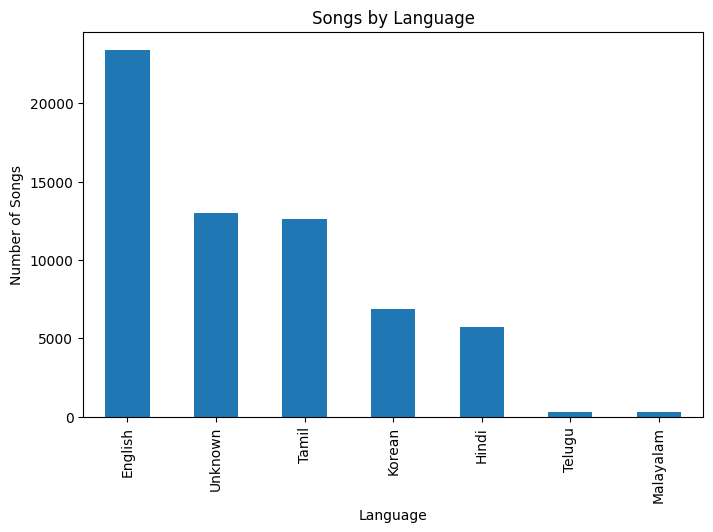

In [41]:
print("---------Data Visualization--------------")
print()
print()

language_counts = df['language'].value_counts()

plt.figure(figsize=(8,5))
language_counts.plot(kind='bar')

plt.title("Songs by Language")
plt.xlabel("Language")
plt.ylabel("Number of Songs")

plt.show()

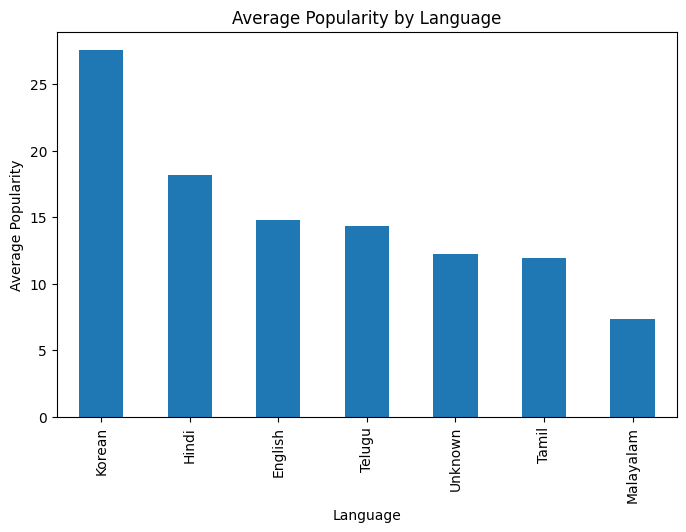

In [43]:
avg_pop = df.groupby(
    'language'
)['popularity'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

avg_pop.plot(kind='bar')

plt.title("Average Popularity by Language")
plt.xlabel("Language")
plt.ylabel("Average Popularity")

plt.show()

In [50]:
top_song_per_language = (
    df.loc[
        df.groupby('language')['popularity'].idxmax()
    ]
)

print(
    top_song_per_language[
        ['language','album_name','album_name','popularity']
    ]
)

        language                                         album_name  \
49479    English                                          Big Dawgs   
7215       Hindi                           Satranga (From "ANIMAL")   
31241     Korean                                               EASY   
6277   Malayalam  Yuvarathnaa (Kannada) [Original Motion Picture...   
45977      Tamil                 Chuttamalle (From "Devara Part 1")   
37322     Telugu          Fear Song (From "Devara Part 1") [Telugu]   
28793    Unknown                                           One Love   

                                              album_name  popularity  
49479                                          Big Dawgs          93  
7215                            Satranga (From "ANIMAL")          83  
31241                                               EASY          88  
6277   Yuvarathnaa (Kannada) [Original Motion Picture...          53  
45977                 Chuttamalle (From "Devara Part 1")          80  
37322

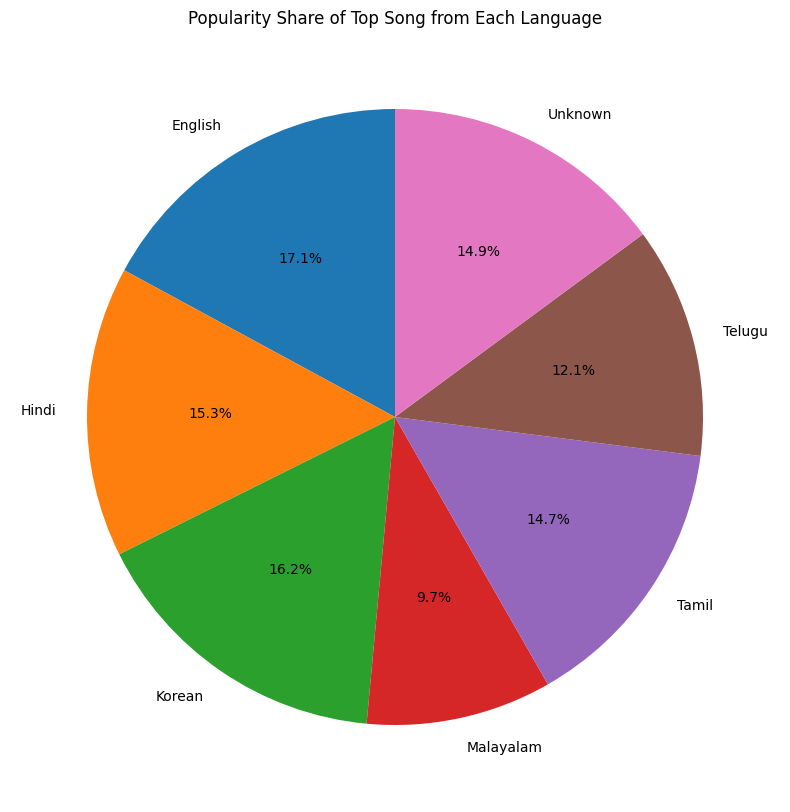

In [51]:
plt.figure(figsize=(10,10))

plt.pie(
    top_song_per_language['popularity'],
    labels=top_song_per_language['language'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Popularity Share of Top Song from Each Language")

plt.show()

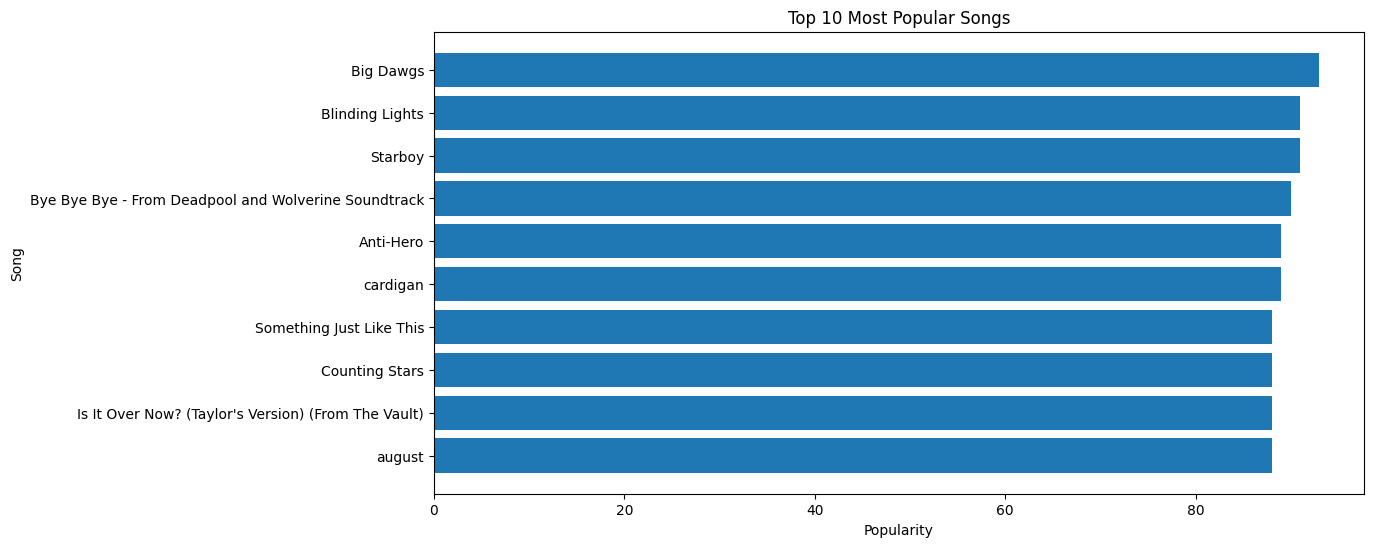

In [45]:
top_songs = df.nlargest(10, 'popularity')

plt.figure(figsize=(12,6))
plt.barh(top_songs['song_name'], top_songs['popularity'])

plt.title("Top 10 Most Popular Songs")
plt.xlabel("Popularity")
plt.ylabel("Song")

plt.gca().invert_yaxis()
plt.show()

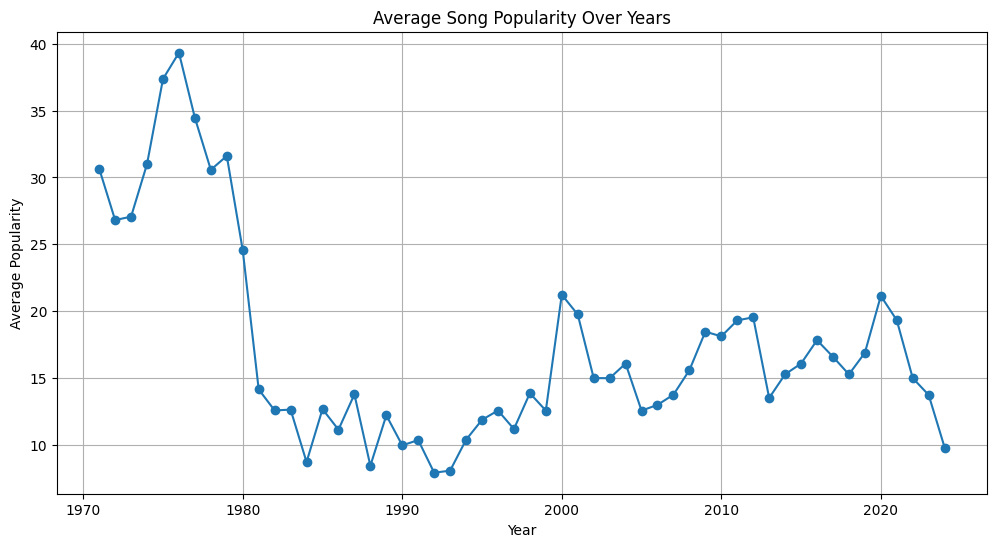

In [52]:
year_pop = (
    df.groupby('year')['popularity']
      .mean()
      .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    year_pop.index,
    year_pop.values,
    marker='o'
)

plt.title("Average Song Popularity Over Years")
plt.xlabel("Year")
plt.ylabel("Average Popularity")

plt.grid(True)

plt.show()

In [53]:
print("--------Machine Learning Model--------")

X = df[
    [
        'danceability',
        'energy',
        'acousticness',
        'tempo',
        'valence'
    ]
]

y = df['popularity']

print("Features Selected Successfully!")

--------Machine Learning Model--------
Features Selected Successfully!


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (49791, 5)
Testing Data Shape: (12448, 5)


In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [56]:
predictions = model.predict(X_test)

print("Predictions Generated!")

Predictions Generated!


In [57]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error:", round(mae,2))
print("R2 Score:", round(r2,2))

Mean Absolute Error: 14.94
R2 Score: 0.03


In [58]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

print(results.head(10))

   Actual  Predicted
0       8   9.601795
1      30  15.159882
2       0  15.807327
3       0  13.795944
4      12  13.667258
5      14  15.886489
6      21  13.843221
7       5  14.173245
8       4  15.481035
9       1  11.942013
